# Random Forest Hyperparameter Tuning Model

**Module:** IT3051 - Fundamentals of Data Mining  
**Project:** Next-Year PM2.5 Air-Quality Risk Classification  
**Model:** Random Forest Classifier  
**Purpose:** Baseline model development and validation

This notebook:

- Loads the chronological train/validation/test datasets created by `07_make_dataset.ipynb`
- Reuses the preprocessing logic from `10_preprocessing_pipeline.ipynb`
- Fits preprocessing **only on training data** to prevent leakage
- Trains a Random Forest hyperparameter tuning model
- Evaluates the model on the validation set
- Reports Accuracy, Macro F1, Classification Report, and Confusion Matrix
- Keeps the test set untouched for later final-model evaluation

> This is a **baseline** Random Forest. Hyperparameter tuning and model optimization are intentionally not performed here.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Make this work when the notebook is run from the project's notebooks folder
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing.preprocessing_pipeline import (
    TARGET_COLUMN,
    prepare_base_dataframe,
    prepare_features_and_target,
    build_preprocessor,
)

print("Imports loaded successfully.")
print("Project root:", project_root)


Imports loaded successfully.
Project root: C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main


## 1. Load Chronological Split Datasets

`07_make_dataset.ipynb` creates chronological splits:

- Training: years up to 2012
- Validation: 2013-2014
- Test: 2015 onward

We load the full split files because they contain both the predictors and target.


In [2]:
processed_dir = project_root / "data" / "processed"

train_path = processed_dir / "train_data.csv"
validation_path = processed_dir / "validation_data.csv"
test_path = processed_dir / "test_data.csv"

required_files = [train_path, validation_path, test_path]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Run 07_make_dataset.ipynb first to create the chronological split files."
        )

identifier_types = {
    "site_id": "string",
    "state_code": "string",
    "county_code": "string",
    "site_num": "string",
}

train_df = pd.read_csv(train_path, dtype=identifier_types, low_memory=False)
validation_df = pd.read_csv(validation_path, dtype=identifier_types, low_memory=False)
test_df = pd.read_csv(test_path, dtype=identifier_types, low_memory=False)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)


Training shape: (13191, 38)
Validation shape: (1783, 38)
Test shape: (1561, 38)


## 2. Confirm the Chronological Split

This check helps confirm that future years are not mixed into the training data.


In [3]:
for name, dataset in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df),
]:
    print(
        f"{name}: {dataset['year'].min()} - {dataset['year'].max()} "
        f"({len(dataset)} rows)"
    )


Training: 1997 - 2012 (13191 rows)
Validation: 2013 - 2014 (1783 rows)
Test: 2015 - 2016 (1561 rows)


## 3. Apply Base Cleaning to Each Split

We use the same base-cleaning function used in the preprocessing notebook.  
Each split is handled separately.


In [4]:
train_prepared = prepare_base_dataframe(train_df)
validation_prepared = prepare_base_dataframe(validation_df)
test_prepared = prepare_base_dataframe(test_df)

print("Base preprocessing completed.")
print("Training shape:", train_prepared.shape)
print("Validation shape:", validation_prepared.shape)
print("Test shape:", test_prepared.shape)


Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Base preprocessing completed.
Training shape: (13191, 38)
Validation shape: (1783, 38)
Test shape: (1561, 38)


## 4. Separate Features and Target

The target is `pm25_risk_category_next_year`.

Identifier columns are excluded by the existing project preprocessing function.


In [5]:
X_train, y_train = prepare_features_and_target(train_prepared)
X_val, y_val = prepare_features_and_target(validation_prepared)
X_test, y_test = prepare_features_and_target(test_prepared)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())


Feature matrix shape: (13191, 33)
Target shape: (13191,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1783, 33)
Target shape: (1783,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1561, 33)
Target shape: (1561,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
X_train: (13191, 33) | y_train: (13191,)
X_val: (1783, 33) | y_val: (1783,)
X_test: (1561, 33) | y_test: (1561,)

Training target distribution:
pm25_risk_category_next_year
Moderate                          6849
Unhealthy for Sensitive Groups    5049
Unhealthy                         1203
Good                                52
Very Unhealthy                      38
Name: count, dtype: int64


## 5. Build and Fit the Preprocessor

Important: the preprocessor is **fitted only on `X_train`**.

The fitted training preprocessor is then used to transform validation and test features.  
This prevents information leakage from future data.


In [6]:
preprocessor = build_preprocessor(X_train)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# Prepare test features with the same fitted transformer,
# but do not use y_test for baseline model selection.
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Numerical features: 29
Categorical features: 4
Preprocessing completed.
Processed training shape: (13191, 2154)
Processed validation shape: (1783, 2154)
Processed test shape: (1561, 2154)


## 6. Create the Baseline Random Forest

No hyperparameter search is performed here.

`random_state=42` is used so the experiment is reproducible.


# Random Forest Hyperparameter Tuning

This notebook tunes the Random Forest model using the existing chronological train/validation split.

**Selection metric:** validation Macro F1, because the target classes are imbalanced.

The test set is deliberately not used during hyperparameter search. It remains untouched for final group evaluation.


In [7]:
from itertools import product
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## 1. Hyperparameter search space

A compact, systematic manual grid is used so that the chronological validation set remains the model-selection set. This avoids random cross-validation that would ignore the time ordering of the project data.

The search varies tree count, tree depth, minimum leaf size, and class weighting.


In [8]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 12, 20],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

total_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["min_samples_leaf"])
    * len(param_grid["class_weight"])
)

print("Total parameter combinations:", total_combinations)
print("Primary selection metric: Validation Macro F1")


Total parameter combinations: 36
Primary selection metric: Validation Macro F1


## 2. Run tuning experiments

Every candidate is trained only on the training set and evaluated on the validation set. Results are ranked primarily by Macro F1 and secondarily by Accuracy.


In [9]:
tuning_results = []

for n_estimators, max_depth, min_samples_leaf, class_weight in product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["min_samples_leaf"],
    param_grid["class_weight"]
):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_processed, y_train)
    pred = model.predict(X_val_processed)

    tuning_results.append({
        "n_estimators": n_estimators,
        "max_depth": "None" if max_depth is None else max_depth,
        "min_samples_leaf": min_samples_leaf,
        "class_weight": "None" if class_weight is None else class_weight,
        "validation_accuracy": accuracy_score(y_val, pred),
        "validation_macro_f1": f1_score(y_val, pred, average="macro", zero_division=0)
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    ["validation_macro_f1", "validation_accuracy"],
    ascending=False
).reset_index(drop=True)

tuning_results_df.head(10)


,n_estimators,max_depth,min_samples_leaf,class_weight,validation_accuracy,validation_macro_f1
0,200,20,4,balanced,0.719013,0.394583
1,400,None,2,balanced,0.763320,0.389044
2,200,20,2,balanced,0.757712,0.387824
3,400,None,4,balanced,0.724061,0.387536
4,200,None,2,balanced,0.764442,0.386608
5,200,None,4,balanced,0.722378,0.382857
6,400,20,4,balanced,0.715648,0.382726
7,400,20,2,balanced,0.756029,0.374245
8,200,12,2,balanced,0.727426,0.370539
9,200,20,1,balanced,0.777342,0.367100


In [10]:
results_dir = project_root / "reports" / "model_results"
pictures_dir = project_root / "reports" / "pictures"
results_dir.mkdir(parents=True, exist_ok=True)
pictures_dir.mkdir(parents=True, exist_ok=True)

tuning_results_path = results_dir / "random_forest_tuning_all_results.csv"
tuning_results_df.to_csv(tuning_results_path, index=False)

print("Saved:", tuning_results_path)


Saved: C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main\reports\model_results\random_forest_tuning_all_results.csv


## 3. Best hyperparameters


In [11]:
best_row = tuning_results_df.iloc[0]

best_n_estimators = int(best_row["n_estimators"])
best_max_depth = None if str(best_row["max_depth"]) == "None" else int(float(best_row["max_depth"]))
best_min_samples_leaf = int(best_row["min_samples_leaf"])
best_class_weight = None if str(best_row["class_weight"]) == "None" else str(best_row["class_weight"])

best_params = {
    "n_estimators": best_n_estimators,
    "max_depth": best_max_depth,
    "min_samples_leaf": best_min_samples_leaf,
    "class_weight": best_class_weight
}

print("Best parameters:", best_params)
print("Best validation Macro F1:", round(float(best_row["validation_macro_f1"]), 6))
print("Corresponding validation Accuracy:", round(float(best_row["validation_accuracy"]), 6))


Best parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 4, 'class_weight': 'balanced'}
Best validation Macro F1: 0.394583
Corresponding validation Accuracy: 0.719013


## 4. Train and evaluate the tuned Random Forest


In [12]:
rf_tuned = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_processed, y_train)
y_val_pred_tuned = rf_tuned.predict(X_val_processed)

tuned_accuracy = accuracy_score(y_val, y_val_pred_tuned)
tuned_macro_f1 = f1_score(y_val, y_val_pred_tuned, average="macro", zero_division=0)

print(f"Tuned Validation Accuracy: {tuned_accuracy:.6f}")
print(f"Tuned Validation Macro F1: {tuned_macro_f1:.6f}")


Tuned Validation Accuracy: 0.719013
Tuned Validation Macro F1: 0.394583


## 5. Baseline vs tuned comparison

The known Random Forest baseline validation results are included for direct comparison.


In [13]:
baseline_accuracy = 0.77005
baseline_macro_f1 = 0.346016

comparison_df = pd.DataFrame({
    "model": ["Random Forest Baseline", "Random Forest Tuned"],
    "validation_accuracy": [baseline_accuracy, tuned_accuracy],
    "validation_macro_f1": [baseline_macro_f1, tuned_macro_f1]
})

comparison_df["accuracy_change"] = comparison_df["validation_accuracy"] - baseline_accuracy
comparison_df["macro_f1_change"] = comparison_df["validation_macro_f1"] - baseline_macro_f1

comparison_df


,model,validation_accuracy,validation_macro_f1,accuracy_change,macro_f1_change
0,Random Forest Baseline,0.770050,0.346016,0.000000,0.000000
1,Random Forest Tuned,0.719013,0.394583,-0.051037,0.048567


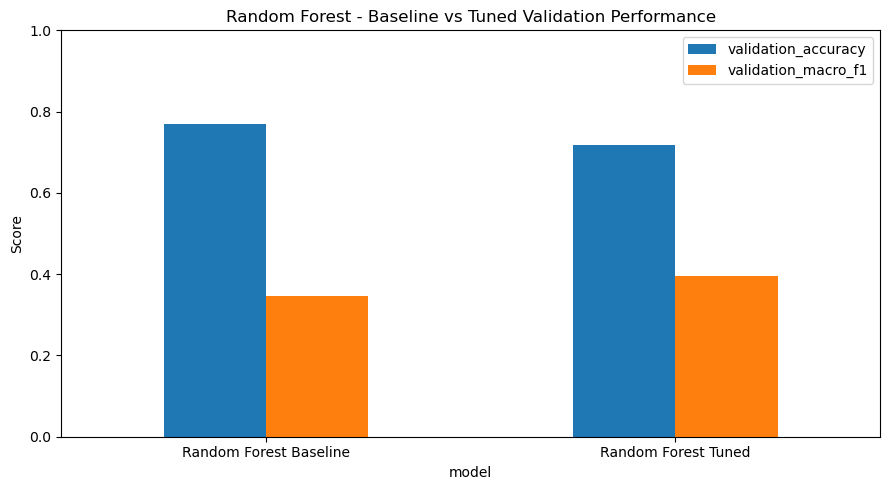

In [14]:
comparison_path = results_dir / "random_forest_baseline_vs_tuned.csv"
comparison_df.to_csv(comparison_path, index=False)

ax = comparison_df.set_index("model")[["validation_accuracy", "validation_macro_f1"]].plot(
    kind="bar", figsize=(9, 5), rot=0
)
ax.set_title("Random Forest - Baseline vs Tuned Validation Performance")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
comparison_plot_path = pictures_dir / "random_forest_baseline_vs_tuned.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches="tight")
plt.show()


## 6. Tuned classification report and confusion matrix


In [15]:
report_dict = classification_report(
    y_val, y_val_pred_tuned, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).T

report_path = results_dir / "random_forest_tuned_classification_report.csv"
report_df.to_csv(report_path)

report_df


,precision,recall,f1-score,support
Good,0.043478,0.800000,0.082474,5.000000
Moderate,0.800413,0.907176,0.850457,1282.000000
Unhealthy,0.422535,0.472441,0.446097,127.000000
Unhealthy for Sensitive Groups,0.586207,0.143258,0.230248,356.000000
Very Unhealthy,0.444444,0.307692,0.363636,13.000000
accuracy,0.719013,0.719013,0.719013,0.719013
macro avg,0.459416,0.526114,0.394583,1783.000000
weighted avg,0.726010,0.719013,0.692119,1783.000000


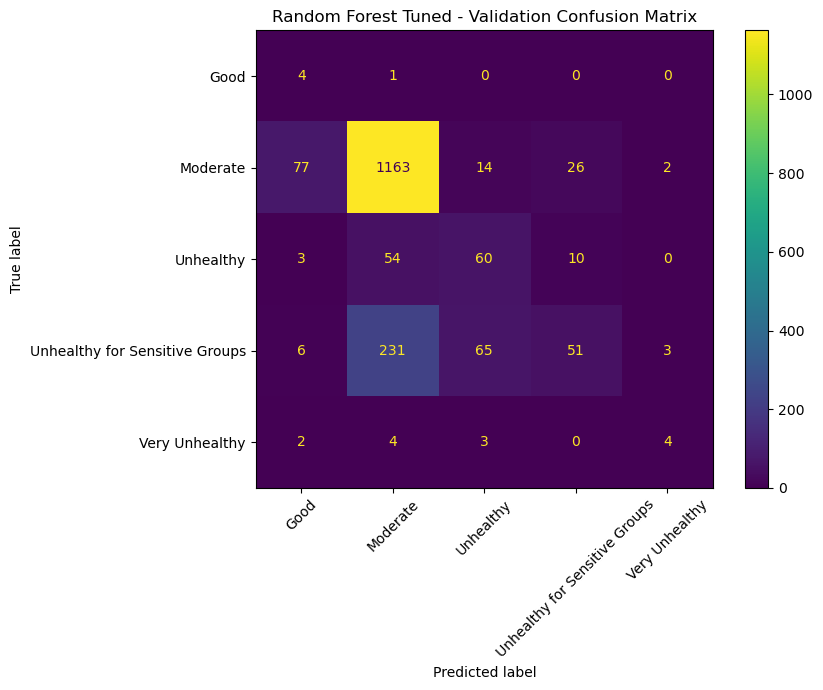

In [16]:
labels = sorted(pd.Series(y_val).dropna().unique())

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_tuned,
    labels=labels,
    xticks_rotation=45,
    cmap="viridis",
    ax=ax
)
ax.set_title("Random Forest Tuned - Validation Confusion Matrix")
plt.tight_layout()

cm_path = pictures_dir / "random_forest_tuned_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()


## 7. Save tuned metrics and best parameters


In [17]:
summary_df = pd.DataFrame([{
    "model": "Random Forest Tuned",
    "validation_accuracy": tuned_accuracy,
    "validation_macro_f1": tuned_macro_f1,
    "baseline_accuracy": baseline_accuracy,
    "baseline_macro_f1": baseline_macro_f1,
    "accuracy_change": tuned_accuracy - baseline_accuracy,
    "macro_f1_change": tuned_macro_f1 - baseline_macro_f1,
    **{f"best_{k}": v for k, v in best_params.items()}
}])

summary_path = results_dir / "random_forest_tuned_results.csv"
summary_df.to_csv(summary_path, index=False)

best_params_df = pd.DataFrame([best_params])
best_params_path = results_dir / "random_forest_best_parameters.csv"
best_params_df.to_csv(best_params_path, index=False)

summary_df


,model,validation_accuracy,validation_macro_f1,baseline_accuracy,baseline_macro_f1,accuracy_change,macro_f1_change,best_n_estimators,best_max_depth,best_min_samples_leaf,best_class_weight
0,Random Forest Tuned,0.719013,0.394583,0.77005,0.346016,-0.051037,0.048567,200,20,4,balanced


## 8. Output check


In [18]:
expected_outputs = [
    tuning_results_path,
    comparison_path,
    report_path,
    summary_path,
    best_params_path,
    comparison_plot_path,
    cm_path
]

for path in expected_outputs:
    print(("OK" if path.exists() else "MISSING"), "-", path)

print("\nIMPORTANT: The test set was not used for hyperparameter selection.")


OK - C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main\reports\model_results\random_forest_tuning_all_results.csv
OK - C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main\reports\model_results\random_forest_baseline_vs_tuned.csv
OK - C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main\reports\model_results\random_forest_tuned_classification_report.csv
OK - C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main\reports\model_results\random_forest_tuned_results.csv
OK - C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main\reports\model_results\random_forest_best_parameters.csv
OK - C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main\reports\pictures\random_forest_baseline_vs_tuned.png
OK - C:\Users\pasin\Downloads\FDM-Mini-Project-main (1)\FDM-Mini-Project-main\reports\pictures\random_forest_tuned_confusion_matrix.png

IMPORTANT: The test set was not used for hyperp